<i>Note, run</i> `conda install -c beautifulsoup4 selenium webdriver-manager --yes` <i>in Anaconda prompt or Spyder Console (with preceding !) before doing this lab. Alternatively, upload this to ArcGIS Online and run in ArcGIS Notebooks.</i>

In [1]:
# !conda install -c conda-forge beautifulsoup4 selenium webdriver-manager --yes

^C
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\ashle\anaconda3

  added / updated specs:
    - beautifulsoup4
    - selenium
    - webdriver-manager


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    beautifulsoup4-4.14.2      |     pyha770c72_0          87 KB  conda-forge
    exceptiongroup-1.3.0       |     pyhd8ed1ab_0          21 KB  conda-forge
    outcome-1.3.0.post0        |     pyhd8ed1ab_1          15 KB  conda-forge
    selenium-4.32.0            |     pyhe01879c_0         320 KB  conda-forge
    selenium-manager-4.32.0    |       h63977a8_0         1.9 MB  conda-forge
    trio-0.24.0                |  py311h1ea47a8_0         829 KB  conda-forge
    trio-websocket-0.12.2      |     pyh29332c3_0          36 KB  conda-forge
    webdriver-manager-4.0.2    |     pyhd8ed

# APIs & Web Scraping
Tons of web data useful for social scientists and humanists

* social media
* news media
* government publications
* organizational records

Two kinds of ways to get data off the web
* Webscraping - i.e. user-facing websites for humans
* APIs - i.e. application-facing, for computers

## What is an API?
* Application Programming Interface
* set of rules and procedures that facilitate interactions between computers and their applications
* allows users to query a remote database over the internet
* take on a variety of formats
* majority adhere to a particular style known as Representational State Transfer or REST
* "RESTful" APIs are convenient because we can use them to query databases using URLs

### HTML
HTTP (Hypertext Transfer Protocol) is one of the main ways computers communicate with each other on the Internet.

<u>Client-server computing model</u>: servers provide a service or resource, and clients request that service. Computers running browsers are examples of a client, while a host in the cloud running is an example of a server.

<u>Request-response protocol</u>: a client sends a request to a server, then receives a response

### requests library

The two most common types of HTTP requests are `GET` and `POST`

* `GET` - request data from the server
* `POST` - submit data to the server

Both types get a response, which can be formatted in HTML or other formats including JSON (similar to Python dictionaries).

#### Making a request

In [2]:
import requests

url = 'https://en.wikipedia.org/wiki/Request–response'
headers = {
'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'
}
# Make the request and store the response
r = requests.get(url, headers=headers)

# Get the result
r.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Request–response - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vec

In [3]:
# Also, check the status code to make sure it downloaded successfully (200 is what we want)
r.status_code

200

In [4]:

# set base url
base_url="https://itunes.apple.com/search"

search_params = {"term":"The Beatles",
                 "media": "music",
                 "entity": "album",
                 "attribute": "artistTerm"}  
# make request
r = requests.get(base_url, params=search_params)

print(r.url)

https://itunes.apple.com/search?term=The+Beatles&media=music&entity=album&attribute=artistTerm


In [5]:
# Inspect the content of the response, parsing the result as text
response_text= r.text
response_text

'\n\n\n{\n "resultCount":47,\n "results": [\n{"wrapperType":"collection", "collectionType":"Album", "artistId":136975, "collectionId":1441133180, "amgArtistId":3644, "artistName":"The Beatles", "collectionName":"The Beatles (The White Album)", "collectionCensoredName":"The Beatles (The White Album)", "artistViewUrl":"https://music.apple.com/us/artist/the-beatles/136975?uo=4", "collectionViewUrl":"https://music.apple.com/us/album/the-beatles-the-white-album/1441133180?uo=4", "artworkUrl60":"https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/60x60bb.jpg", "artworkUrl100":"https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/100x100bb.jpg", "collectionPrice":19.99, "collectionExplicitness":"notExplicit", "trackCount":32, "copyright":"This Compilation ℗ 2009 Calderstone Productions Limited (a division of Universal Music Group)", "country":"USA", "curre

In [6]:
import json
data = json.loads(response_text)
data

{'resultCount': 47,
 'results': [{'wrapperType': 'collection',
   'collectionType': 'Album',
   'artistId': 136975,
   'collectionId': 1441133180,
   'amgArtistId': 3644,
   'artistName': 'The Beatles',
   'collectionName': 'The Beatles (The White Album)',
   'collectionCensoredName': 'The Beatles (The White Album)',
   'artistViewUrl': 'https://music.apple.com/us/artist/the-beatles/136975?uo=4',
   'collectionViewUrl': 'https://music.apple.com/us/album/the-beatles-the-white-album/1441133180?uo=4',
   'artworkUrl60': 'https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/60x60bb.jpg',
   'artworkUrl100': 'https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/100x100bb.jpg',
   'collectionPrice': 19.99,
   'collectionExplicitness': 'notExplicit',
   'trackCount': 32,
   'copyright': 'This Compilation ℗ 2009 Calderstone Productions Limited (a division of

In [7]:
data.keys()

dict_keys(['resultCount', 'results'])

In [8]:
data['resultCount']

47

In [9]:
# Get first result
data['results'][0]

{'wrapperType': 'collection',
 'collectionType': 'Album',
 'artistId': 136975,
 'collectionId': 1441133180,
 'amgArtistId': 3644,
 'artistName': 'The Beatles',
 'collectionName': 'The Beatles (The White Album)',
 'collectionCensoredName': 'The Beatles (The White Album)',
 'artistViewUrl': 'https://music.apple.com/us/artist/the-beatles/136975?uo=4',
 'collectionViewUrl': 'https://music.apple.com/us/album/the-beatles-the-white-album/1441133180?uo=4',
 'artworkUrl60': 'https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/60x60bb.jpg',
 'artworkUrl100': 'https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/fa/5b/89/fa5b898d-bad6-e053-4195-260e5c74f2bb/00602567725466.rgb.jpg/100x100bb.jpg',
 'collectionPrice': 19.99,
 'collectionExplicitness': 'notExplicit',
 'trackCount': 32,
 'copyright': 'This Compilation ℗ 2009 Calderstone Productions Limited (a division of Universal Music Group)',
 'country': 'USA',
 'currency': 'USD'

In [15]:
# Process all the results
import pandas as pd
albums =pd.DataFrame(data['results'])
albums[albums["releaseDate"]<"1970"]
albums[["artistName", "collectionName", "releaseDate"]].sort_values("releaseDate")

,artistName,collectionName,releaseDate
12,The Beatles,Please Please Me,1963-03-22T08:00:00Z
14,The Beatles,With The Beatles,1963-11-22T08:00:00Z
8,The Beatles,A Hard Day's Night,1964-07-10T07:00:00Z
18,The Beatles,Beatles For Sale,1964-12-04T08:00:00Z
9,The Beatles,Help!,1965-08-06T07:00:00Z
3,The Beatles,Rubber Soul,1965-12-03T08:00:00Z
6,The Beatles,Revolver,1966-08-05T07:00:00Z
17,The Beatles,Revolver (2022 Mix),1966-08-05T07:00:00Z
32,The Beatles,Revolver (Super Deluxe),1966-08-05T07:00:00Z
45,The Beatles,Strawberry Fields Forever / Penny Lane - Single,1967-02-13T08:00:00Z


## Why Webscrape?

Benefits:
* Pretty much any content that can be viewed on a webpage can be scraped. (https://epps.utdallas.edu/about/faculty/)
* No API needed
* No rate-limiting or authentication (usually)  

Challenges:
* Rarely tailored for researchers
* Messy, unstructured, inconsistent
* Entirely site-dependent

Webscraping vs. APIs rule of thumb:
* Check for API first. If the API is not available, scrape.*
* If the site allows you to do so, scrape.
* Wikipedia and IMDB both allow scraping, so those are easy sites to start with.

### HTML
HyperText Markup Language (HTML) is a language that most webpages are written in.

It is made up of tags like so:
```html
    <html>
        <head>
        </head>
        <body>
        </body>
    </html>
```

Other tags include:

* `<div>` - general division or area of the page
* `<b>` - bolds text
* `<i>` - italicizes text
* `<table>` - denotes a table on the page
* `<form>` - form for input

### The tools
1. [Requests](http://docs.python-requests.org/en/latest/user/quickstart/)
2. [Beautiful Soup](http://www.crummy.com/software/BeautifulSoup/bs4/doc/)
3. [Selenium](https://www.selenium.dev/)

In [38]:
# import required modules
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

### Step 1 - Make a GET request and read response HTML

In [18]:

# Set Chrome options
chrome_options = Options()
chrome_options.add_argument("--headless")  # Run in background
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--no-sandbox")

# Initialize Chrome with WebDriver Manager
with webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options) as browser:
    browser.get('https://house.texas.gov/members/')
    req = browser.page_source

# Now you can use 'req' as the HTML source
src = req
print(src[:1000])  # Print first 1000 characters for verification

<html lang="en"><head><style class="vjs-styles-defaults">
      .video-js {
        width: 300px;
        height: 150px;
      }

      .vjs-fluid:not(.vjs-audio-only-mode) {
        padding-top: 56.25%
      }
    </style>
  <meta http-equiv="Content-Type" content="text/html; charset=utf-8">
  
  <meta http-equiv="Cache-Control" content="max-age=31536000">
  <meta http-equiv="Content-Security-Policy:" content="object-src 'self'; script-src 'self'; img-src 'self', 'upgrade-insecure-requests'">

  <meta name="csrf-token" content="Jit9tmsP7fIamXQyeueWY60cSabIYW4NCSbct6mM">
  <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">

  <meta name="description" content=" Website for the Texas House of Representatives provides information on legislation, committees, sessions, and the Texas House">
  <meta name="keywords" content="Texas House of Representatives, legislature, legislation, house, senate, bills, bill">
  <meta name="author" content="Texas House of R

### Step 2 - Soup It
Now we use the `BeautifulSoup` function to parse the reponse into an HTML tree. This returns an object (called a soup object) which contains all of the HTML in the original document.

In [19]:
# parse the response into an HTML tree
soup = BeautifulSoup(src)
# take a look
print(soup.prettify()[:1000])

<html lang="en">
 <head>
  <style class="vjs-styles-defaults">
   .video-js {
        width: 300px;
        height: 150px;
      }

      .vjs-fluid:not(.vjs-audio-only-mode) {
        padding-top: 56.25%
      }
  </style>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="max-age=31536000" http-equiv="Cache-Control"/>
  <meta content="object-src 'self'; script-src 'self'; img-src 'self', 'upgrade-insecure-requests'" http-equiv="Content-Security-Policy:"/>
  <meta content="Jit9tmsP7fIamXQyeueWY60cSabIYW4NCSbct6mM" name="csrf-token"/>
  <meta content="width=device-width, initial-scale=1, shrink-to-fit=no" name="viewport"/>
  <meta content=" Website for the Texas House of Representatives provides information on legislation, committees, sessions, and the Texas House" name="description"/>
  <meta content="Texas House of Representatives, legislature, legislation, house, senate, bills, bill" name="keywords"/>
  <meta content="Texas House of Representativ

### Step 3 - Find elements
BeautifulSoup has a number of functions to find things on a page. Like other webscraping tools, Beautiful Soup lets you find elements by their:

HTML tags
HTML Attributes
CSS Selectors
Let's search first for <b>HTML tags</b>.

The function `find_all` searches the soup tree to find all the elements with an a particular HTML tag, and returns all of those elements.

What does the example below do?

In [20]:
# find all elements in a certain tag
soup.find_all("button")

[<button aria-controls="gov-banner" aria-expanded="false" class="usa-accordion__button usa-banner__button"><span class="usa-banner__button-text">Here's how you know</span></button>,
 <button class="usa-menu-btn">Menu</button>,
 <button class="usa-nav__close"><img alt="close" role="img" src="https://www.house.texas.gov/images/uswds/close.svg"/></button>,
 <button aria-controls="extended-nav-section-one" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Members</span></button>,
 <button aria-controls="extended-nav-section-two" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Committees</span></button>,
 <button aria-controls="extended-nav-section-three" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Broadcast Events</span></button>,
 <button aria-label="SubmitSearch" class="usa-button" type="submit"><img alt="" class="usa-search__submit-icon" src="/images/vendor/uswds/src/usa-icons-bg/search--white.svg"/></button>,
 <b

That's a lot! Many elements on a page will have the same html tag. For instance, if you search for everything with the a tag, you're likely to get a lot of stuff, much of which you don't want. What if we wanted to search for HTML tags ONLY with certain attributes, like particular CSS classes?

We can do this by adding an additional argument to the `find_all`

In the example below, we are finding all the a tags, and then filtering those with class = "sidemenu".

In [21]:
# Get only the 'a' tags in 'sidemenu' class
soup("button", class_="usa-accordion__button")

[<button aria-controls="gov-banner" aria-expanded="false" class="usa-accordion__button usa-banner__button"><span class="usa-banner__button-text">Here's how you know</span></button>,
 <button aria-controls="extended-nav-section-one" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Members</span></button>,
 <button aria-controls="extended-nav-section-two" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Committees</span></button>,
 <button aria-controls="extended-nav-section-three" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Broadcast Events</span></button>]

In [22]:
# Alternatively can get the same results using CSS-style notation:
soup.select("button.usa-accordion__button")

[<button aria-controls="gov-banner" aria-expanded="false" class="usa-accordion__button usa-banner__button"><span class="usa-banner__button-text">Here's how you know</span></button>,
 <button aria-controls="extended-nav-section-one" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Members</span></button>,
 <button aria-controls="extended-nav-section-two" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Committees</span></button>,
 <button aria-controls="extended-nav-section-three" aria-expanded="false" class="usa-accordion__button usa-nav__link"><span>Broadcast Events</span></button>]

However, looking at the results, it seems that the District number is missing. Instead we need to search for the parent element. Using Chrome Dev-Tools, we can see that the parent element is a td (table column element) with a class of `members-img-center`.

In [23]:
# Get all the representative elements
soup.select('div.usa-card')

[<div class="usa-card width-card-lg"><div class="usa-card__container border-gold bg-primary-darker tx-lines-bg"><div class="usa-card__media padding-top-2 padding-x-6"><div class="usa-card__img circle-card border-2px border-white shadow-5 hover:border-gold"><a href="https://house.texas.gov/members/4395"><img alt="Image of Rep. Alders, Daniel" height="175" src="/images/members/4395.jpg?v=1" width="125"/></a></div></div><header class="usa-card__header text-center"><span class="text-base-lighter font-serif-3xs border-bottom border-gold">Representative</span><h2 class="usa-card__heading text-base-lighter font-serif-md padding-top-1">Alders, Daniel</h2></header><div class="usa-card__body text-center"><h3 class="text-base-lighter font-serif-2xs">District 6</h3></div><div class="usa-card__footer text-center"><a href="https://house.texas.gov/members/4395"><button class="usa-button">Member Page</button></a></div></div></div>,
 <div class="usa-card width-card-lg"><div class="usa-card__container b

In [36]:
import pandas as pd
# For each of those member entities get their info
names = [name.get_text() for name in soup.select('h2.usa-card__heading')]
districts = [district.get_text() for district in soup.select('.usa-card__body h3')]
pd.DataFrame({"Name":names, "District":districts})

,Name,District
0,"Alders, Daniel",District 6
1,"Allen, Alma A.",District 131
2,"Anchía, Rafael",District 103
3,"Ashby, Trent",District 9
4,"Barry, Jeff",District 29
...,...,...
145,"Ward Johnson, Charlene",District 139
146,"Wharton, Trey",District 12
147,"Wilson, Terry M.",District 20
148,"Wu, Gene",District 137


Use the [REST Countries API](https://restcountries.com/) to get a list of all the countries that have Spanish (language code="spa") as an official language. Print the name and population of each country. Have the table sorted by population, from largest to smallest, and use comma separation number formatting for the population (e.g. 1,000,000).

In [ ]:
# import required modules
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

In [44]:
import pandas as pd
url = "https://restcountries.com/v3.1/all?fields=name,languages,population"
response = requests.get(url)
countries = response.json()
#craate lists for countries
names = [c["name"]["common"] for c in countries if c.get('languages') and 'spa' in c['languages']]
populations = [c["population"] for c in countries if c.get("languages") and "spa" in c["languages"]]
#dataframe :)
df = pd.DataFrame({"Country": names, "Population": populations})
df = df.sort_values(by = "Population", ascending = False)
df['Population'] = df['Population'].apply(lambda x: f"{x:,}")
df

,Country,Population
0,Mexico,"130,575,786"
14,Colombia,"53,057,212"
19,Spain,"49,315,949"
8,Argentina,"46,735,004"
5,Peru,"34,350,244"
16,Venezuela,"28,517,000"
15,Chile,"20,206,953"
23,Ecuador,"18,103,660"
9,Guatemala,"18,079,810"
21,Bolivia,"11,365,333"


Use BeautifulSoup to scrape the [Texas Senate membership webpage](https://senate.texas.gov/directory.php) to get a list of the Texas State Senator information. Create a list of Python dictionaries containing each Senator's name, district, and party

In [62]:
url = "https://senate.texas.gov/directory.php"
resp = requests.get(url)
soup = BeautifulSoup(resp.text, "html.parser")
names = [name.get_text(strip=True) for name in soup.select('a[id^="dist"]')]
districts = [a["id"].replace("dist", "") for a in soup.select('a[id^="dist"]')]
parties = []
for a in soup.select('a[id^="dist"]'):
    # Find the parent td element
    parent_td = a.find_parent('td', class_='md_sdp')
    if parent_td:
        # Find all monosp spans in this td
        monosp_spans = parent_td.find_all('span', class_='monosp')
        party_found = False
        for span in monosp_spans:
            text = span.get_text()
            if 'Party:' in text:
                # Get the next sibling text or the text after "Party:"
                parent_text = span.parent.get_text()
                if 'Party:' in parent_text:
                    party_text = parent_text.split('Party:')[1].strip().split()[0]
                    parties.append(party_text)
                    party_found = True
                    break
        if not party_found:
            parties.append('Unknown')
    else:
        parties.append('Unknown')

# Create DataFrame
df = pd.DataFrame({"Name": names, "District": districts, "Party": parties})
df

,Name,District,Party
0,Bryan Hughes,1,Republican
1,Bob Hall,2,Republican
2,Robert Nichols,3,Republican
3,District 4 Constituent Services,4,—
4,Charles Schwertner,5,Republican
5,Carol Alvarado,6,Democrat
6,Paul Bettencourt,7,Republican
7,Angela Paxton,8,Republican
8,District 9 Constituent Services,9,—
9,Phil King,10,Republican


Convert this list of dictionaries to a pandas DataFrame and save it to a .CSV file.

In [63]:
# Save to CSV file
df.to_csv("texas_senators.csv", index=False)

Use pandas to create a pie chart of Senate membership by party ([Hint](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html))

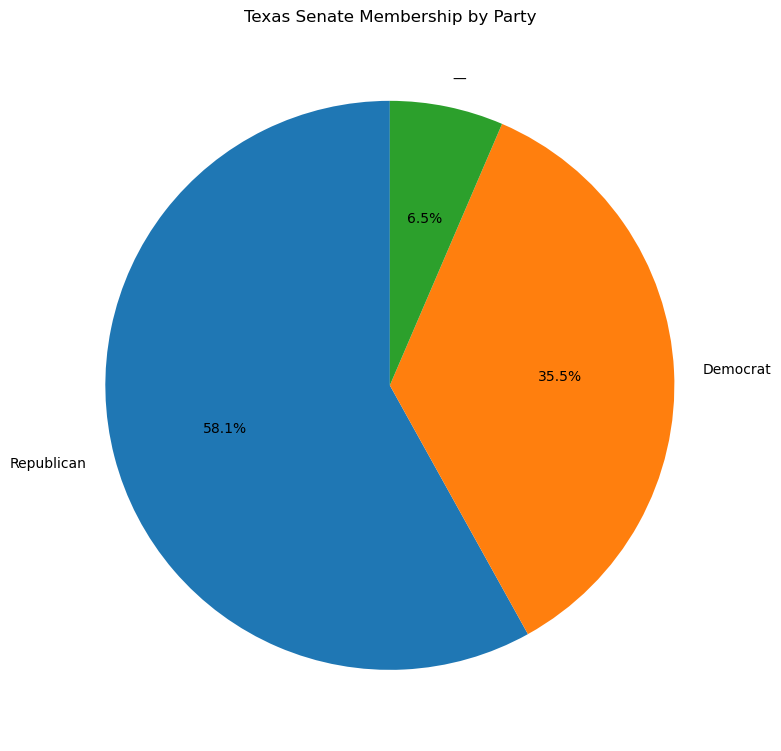

In [65]:
import matplotlib.pyplot as plt
# Create pie chart of party membership
party_counts = df['Party'].value_counts()
party_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    figsize=(8, 8),
    title='Texas Senate Membership by Party'
)
plt.ylabel('')  # Remove the default 'Party' ylabel
plt.tight_layout()
plt.show()
